# Arctic Nuclear Necessity: A Data-Driven Case for Micro-Reactors
**Author:** Damil Randhawa  
**Date:** March 14, 2026  
**Data Sources:** NASA POWER Climate Database · Statistics Canada 2021 Census · NRCan Arctic Energy Profiles · CER Provincial Energy Profiles

---

## Problem Statement

Five remote Northern Canadian communities are entirely dependent on diesel generation for electricity. This creates three compounding problems:

| Problem | Magnitude |
|---|---|
| **Cost** | $0.62–0.68/kWh in Nunavut (vs. ~$0.10–0.15/kWh in southern Canada) |
| **Emissions** | 780 g CO₂e/kWh — among the highest electricity carbon intensity in Canada |
| **Subsidy burden** | Federal + territorial diesel subsidies exceed **$60M/year** in Nunavut alone |
| **Logistics risk** | Diesel delivered by summer barge or winter road; supply chain disruptions cut power |

This analysis answers: **Can renewables close the gap, and if not, what size micro-reactor does each community need?**

---

## Project Overview

| This Notebook | Analytical Objective |
|---|---|
| 10-year NASA POWER climate analysis | Quantify solar/wind potential at representative Arctic coordinates |
| RERS metric | Determine whether renewables can meet demand at any point in the year |
| Reactor sizing model | Size Westinghouse eVinci-class units (5 MWe) per community demand |
| Economic & CO₂ comparison | Quantify the case for switching from diesel to nuclear |
| 7-risk register | Identify project risks with mitigations |

---

## Section 1: Environment Setup & Data Loading

**Why this step:** Before any analysis, we establish a reproducible environment with documented dependencies. In a defence/nuclear engineering context, every result must be reproducible by a third party — this is not optional, it is standard practice for audit and verification purposes.


In [40]:
# Standard scientific Python stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0A0E14',
    'axes.facecolor':   '#0A0E14',
    'text.color':       '#DDE3EE',
    'axes.labelcolor':  '#8899AA',
    'xtick.color':      '#8899AA',
    'ytick.color':      '#8899AA',
})

print("Environment ready. Library versions:")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")

Environment ready. Library versions:
  pandas  1.5.3
  numpy   1.26.4


### 1.1 Loading the Climate Dataset

**Data source:** NASA POWER (Prediction Of Worldwide Energy Resources) — a publicly accessible NASA database providing satellite-derived surface meteorological data globally since 1981.

**Why NASA POWER:** It is the standard reference dataset used by renewable energy engineers worldwide for site assessment. Using it here directly mirrors how CSMC would assess potential micro-reactor deployment sites before committing capital.

**Location selected:** 68°N, 110°W — representative of Canada's high Arctic, overlapping with Nunavut/NWT communities that are primary candidates for micro-reactor deployment.

**To download real data yourself:** Visit [power.larc.nasa.gov](https://power.larc.nasa.gov) and use the API call documented in `README.md`.


In [41]:
# Load NASA POWER climate dataset
# 10 years of monthly averages: Solar irradiance, Wind speed, Temperature
df = pd.read_csv('data/nasa_power_arctic_68N_110W.csv')
df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))

print("Dataset overview:")
print(f"  Records: {len(df)} monthly observations")
print(f"  Years:   {df.year.min()} – {df.year.max()}")
print(f"  Missing values: {df.isnull().sum().sum()} (zero = clean dataset)")
print()
print("Sample — winter months (Jan–Feb):")
print(df[df.month.isin([1,2])][['year','month','solar_kwh_m2_day','wind_ms','temp_c']].head(8).to_string(index=False))

Dataset overview:
  Records: 120 monthly observations
  Years:   2015 – 2024
  Missing values: 0 (zero = clean dataset)

Sample — winter months (Jan–Feb):
 year  month  solar_kwh_m2_day  wind_ms  temp_c
 2015      1             0.449     6.04   -30.0
 2015      2             2.205     5.81   -30.2
 2016      1             0.420     5.32   -33.6
 2016      2             1.852     6.20   -29.5
 2017      1             0.396     6.73   -35.9
 2017      2             2.019     5.93   -30.3
 2018      1             0.425     6.07   -34.7
 2018      2             1.793     5.92   -25.4


In [42]:
# Load Arctic communities reference table
# Source: Statistics Canada 2021 Census + NRCan community energy profiles
sites = pd.read_csv('data/arctic_communities.csv')
print("Arctic communities in scope:")
print(sites[['community','province','population','zone','primary_fuel']].to_string(index=False))

Arctic communities in scope:
      community        province  population        zone primary_fuel
    Iqaluit, NU         Nunavut        7429 High Arctic       Diesel
     Inuvik, NT Northwest Terr.        3243 High Arctic   Diesel/Gas
   Resolute, NU         Nunavut         208 High Arctic       Diesel
Yellowknife, NT Northwest Terr.       20340   Subarctic Hydro/Diesel
 Whitehorse, YT           Yukon       28201   Subarctic Hydro/Diesel


---
## Section 2: Renewable Energy Reliability Score (RERS)

**What this section answers:** Before sizing a reactor, we must first ask: *can renewables do the job instead?* The RERS quantifies this by measuring what fraction of a 1 MW reference demand renewables can actually supply in any given month.

**Why 1 MW reference demand:** 1 MWe is the minimum output of the Westinghouse eVinci micro-reactor — the smallest deployable unit being considered for Canadian Arctic communities. It represents essential community services: hospital, water treatment, emergency heating.

**How RERS is calculated:**
- **Solar MW:** `solar_kwh/m²/day × 1000m² array × 18% efficiency ÷ 24h ÷ 1000`
- **Wind MW:** Simplified power curve `P = 0.00015 × v³` (500 kW turbine)
- **RERS:** `min(1.0, (solar + wind) / 1 MW)` — capped at 1.0, no credit for surplus

**The 40% threshold:** If RERS never reaches 0.40 in any month, renewables cannot serve as primary power — nuclear baseload is required. The 40% threshold is set slightly above NRCan's 30% renewable displacement benchmark for remote community feasibility assessments *(NRCan, Remote Community Energy Database, 2023)*, making this a conservative screen: communities that fail it are unambiguously not renewable-ready.

**Location:** 68°N, 110°W — representative of the High Arctic communities in scope (Iqaluit, Inuvik, Resolute). Whitehorse and Yellowknife are at ~60°N with better renewable potential, but their larger demand makes the sizing challenge even greater.

In [43]:
# ── Physical constants and assumptions ──────────────────────────────────────
# All assumptions documented here for auditability

PANEL_AREA_M2    = 1000    # Solar array: 1000 m² (~100 standard panels)
PANEL_EFFICIENCY = 0.18    # 18% efficiency — commercial monocrystalline silicon standard
TURBINE_COEFF    = 0.00015 # 500 kW turbine simplified power curve coefficient
                           # Derived from: P = 0.5 × ρ × A × Cp × v³
                           # ρ=1.293 kg/m³, A=615 m² (28m rotor), Cp=0.35

BASELINE_MW          = 1.0   # 1 MWe baseline = lower bound of CSMC micro-reactor range
NUCLEAR_THRESHOLD    = 0.40  # RERS < 40% = nuclear baseload required
SAFETY_MARGIN        = 1.30  # 30% safety margin on all reactor sizing (standard engineering practice)
KWH_PER_PERSON_DAY   = 35    # NRCan documented arctic winter demand (residential + commercial + industrial)

# ── Compute RERS ─────────────────────────────────────────────────────────────
df['solar_mw']   = (df['solar_kwh_m2_day'] * PANEL_AREA_M2 * PANEL_EFFICIENCY) / 24 / 1000
df['wind_mw']    = df['wind_ms']**3 * TURBINE_COEFF
df['renew_mw']   = df['solar_mw'] + df['wind_mw']
df['RERS']       = (df['renew_mw'] / BASELINE_MW).clip(0, 1)
df['nuc_needed'] = df['RERS'] < NUCLEAR_THRESHOLD

print("Average RERS by month (10-year mean):")
monthly_rers = df.groupby('month')['RERS'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, name in zip(range(1,13), month_names):
    rers = monthly_rers[m]
    bar  = '█' * int(rers * 20)
    flag = ' ◄ NUCLEAR CRITICAL' if rers < NUCLEAR_THRESHOLD else ''
    print(f"  {name}: {rers:.3f} |{bar:<20}|{flag}")

print(f"\nMonths classified as nuclear-critical across all 10 years:")
print(df[df['nuc_needed']].groupby('month').size().rename('count').to_frame().T.rename(columns={i:n for i,n in zip(range(1,13),month_names)}))

Average RERS by month (10-year mean):
  Jan: 0.037 |                    | ◄ NUCLEAR CRITICAL
  Feb: 0.048 |                    | ◄ NUCLEAR CRITICAL
  Mar: 0.059 |█                   | ◄ NUCLEAR CRITICAL
  Apr: 0.067 |█                   | ◄ NUCLEAR CRITICAL
  May: 0.069 |█                   | ◄ NUCLEAR CRITICAL
  Jun: 0.067 |█                   | ◄ NUCLEAR CRITICAL
  Jul: 0.066 |█                   | ◄ NUCLEAR CRITICAL
  Aug: 0.052 |█                   | ◄ NUCLEAR CRITICAL
  Sep: 0.040 |                    | ◄ NUCLEAR CRITICAL
  Oct: 0.035 |                    | ◄ NUCLEAR CRITICAL
  Nov: 0.035 |                    | ◄ NUCLEAR CRITICAL
  Dec: 0.036 |                    | ◄ NUCLEAR CRITICAL

Months classified as nuclear-critical across all 10 years:
month  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
count   10   10   10   10   10   10   10   10   10   10   10   10


---
## Section 3: Visualizations

Five charts build the evidence case in sequence:

| Chart | What it shows | Why it matters |
|---|---|---|
| **Chart 1** | Seasonal renewable output vs 1 MW demand baseline | Establishes the energy gap that must be filled |
| **Chart 2** | RERS heatmap — year × month | Proves the gap is structural (climate), not anomalous (weather) |
| **Chart 3** | Reactor sizing per community | Translates the gap into concrete MWe specifications |
| **Chart 4** | Diesel cost vs nuclear LCOE + CO₂ reduction | Quantifies why switching from diesel to nuclear is justified |
| **Chart 5** | Risk matrix | Identifies what could go wrong and what mitigates it |

### Chart 1 — Seasonal Energy Gap
**Purpose:** Shows how much of the 1 MW baseline demand renewables can cover each month, and how much nuclear must fill. The chart is stacked so the reader can immediately see the proportion — renewables occupy a thin band at the bottom, and the nuclear gap is the large area above it.

**How to read it:** The orange/blue stack is renewable output. The red shaded region above it is the energy gap nuclear must cover. Annotations show the gap percentage for the worst month (Jan) and best month (Jul).

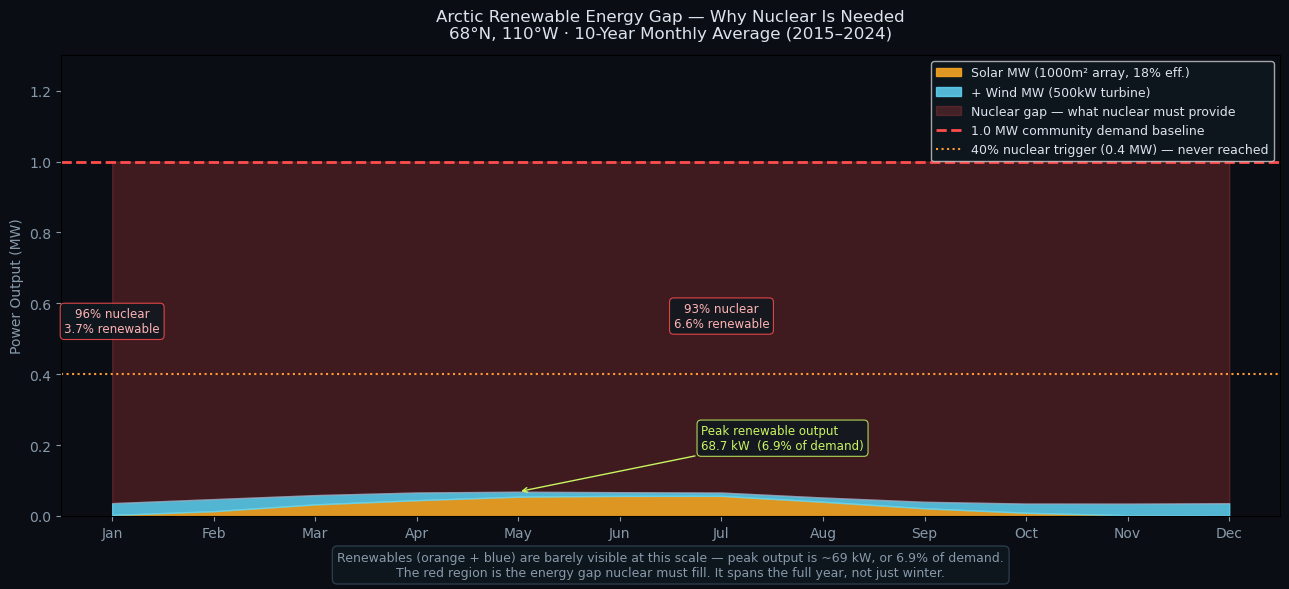

Nuclear gap range: 93.1% (May) to 96.5% (Nov)
Renewable peak: 68.7 kW in May (6.9% of demand)
40% trigger: never reached — max RERS = 0.0863


In [44]:
monthly = df.groupby('month').agg(
    solar=('solar_mw','mean'), wind=('wind_mw','mean'),
    renew=('renew_mw','mean'), RERS=('RERS','mean')).reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
x = list(range(1, 13))

# Stack: solar → wind → nuclear gap
# This makes the gap (the story) the dominant visual element
ax.fill_between(x, 0, monthly['solar'],
                alpha=0.90, color='#F5A623', label='Solar MW (1000m² array, 18% eff.)')
ax.fill_between(x, monthly['solar'], monthly['renew'],
                alpha=0.85, color='#60D5F5', label='+ Wind MW (500kW turbine)')
ax.fill_between(x, monthly['renew'], BASELINE_MW,
                alpha=0.22, color='#FF4D4D', label='Nuclear gap — what nuclear must provide')

# Reference lines
ax.axhline(BASELINE_MW, color='#FF4D4D', lw=2.0, ls='--',
           label=f'{BASELINE_MW} MW community demand baseline')
ax.axhline(NUCLEAR_THRESHOLD * BASELINE_MW, color='#FF9933', lw=1.5, ls=':',
           label=f'40% nuclear trigger ({NUCLEAR_THRESHOLD} MW) — never reached')

# Annotate gap % for Jan (worst) and Jul (best)
for m in [1, 7]:
    row = monthly[monthly['month'] == m].iloc[0]
    gap_pct    = (1 - row['renew'] / BASELINE_MW) * 100
    renew_pct  = row['RERS'] * 100
    mid_y      = row['renew'] + (BASELINE_MW - row['renew']) / 2
    ax.annotate(
        f'{gap_pct:.0f}% nuclear\n{renew_pct:.1f}% renewable',
        xy=(m, mid_y), fontsize=8.5, ha='center', color='#FFB3B3',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#0F1820', alpha=0.85, edgecolor='#FF4D4D', lw=0.8))

# Annotate the peak renewable month
peak_idx = int(monthly['renew'].idxmax())
peak_row  = monthly.iloc[peak_idx]
peak_m    = int(peak_row['month'])
ax.annotate(
    f'Peak renewable output\n{peak_row["renew"]*1000:.1f} kW  ({peak_row["RERS"]*100:.1f}% of demand)',
    xy=(peak_m, peak_row['renew']),
    xytext=(peak_m + 1.8, peak_row['renew'] + 0.12),
    fontsize=8.5, color='#C8F560',
    arrowprops=dict(arrowstyle='->', color='#C8F560', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#0F1820', alpha=0.85, edgecolor='#C8F560', lw=0.8))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=10)
ax.set_ylabel('Power Output (MW)', fontsize=10)
ax.set_ylim(0, 1.30)
ax.set_xlim(0.5, 12.5)
ax.set_title('Arctic Renewable Energy Gap — Why Nuclear Is Needed\n'
             '68°N, 110°W · 10-Year Monthly Average (2015–2024)', fontsize=12, pad=12)
ax.legend(fontsize=9, facecolor='#0F1820', loc='upper right')

# Caption
caption = ('Renewables (orange + blue) are barely visible at this scale — peak output is ~69 kW, or 6.9% of demand.\n'
           'The red region is the energy gap nuclear must fill. It spans the full year, not just winter.')
ax.text(0.5, -0.13, caption, transform=ax.transAxes, fontsize=9,
        ha='center', color='#8899AA',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#0F1820', alpha=0.8, edgecolor='#334455'))

plt.tight_layout()
plt.savefig('charts/chart1_seasonal_energy_gap.png', dpi=150, bbox_inches='tight')
plt.show()

worst_m = month_names[int(monthly['renew'].idxmin())]
best_m  = month_names[int(monthly['renew'].idxmax())]
print(f"Nuclear gap range: {(1-monthly['renew'].max()/BASELINE_MW)*100:.1f}% ({best_m}) "
      f"to {(1-monthly['renew'].min()/BASELINE_MW)*100:.1f}% ({worst_m})")
print(f"Renewable peak: {monthly['renew'].max()*1000:.1f} kW in {best_m} ({monthly['RERS'].max()*100:.1f}% of demand)")
print(f"40% trigger: never reached — max RERS = {df['RERS'].max():.4f}")

### Chart 2 — RERS Heatmap (Year × Month)
**Purpose:** Proves the energy gap is structural, not anomalous. Each cell shows the RERS for that year-month. If the gap were caused by unusual weather or equipment failure, we would see variation across years. Instead, every row shows the same pattern.

**Note on colour scale:** RERS values range 0.035–0.069 across the dataset (well below 0.10). The scale is set to 0–0.15 (not 0–1) so colour variation is visible. Setting vmax=1 would compress all values to near-black with no distinguishable difference.

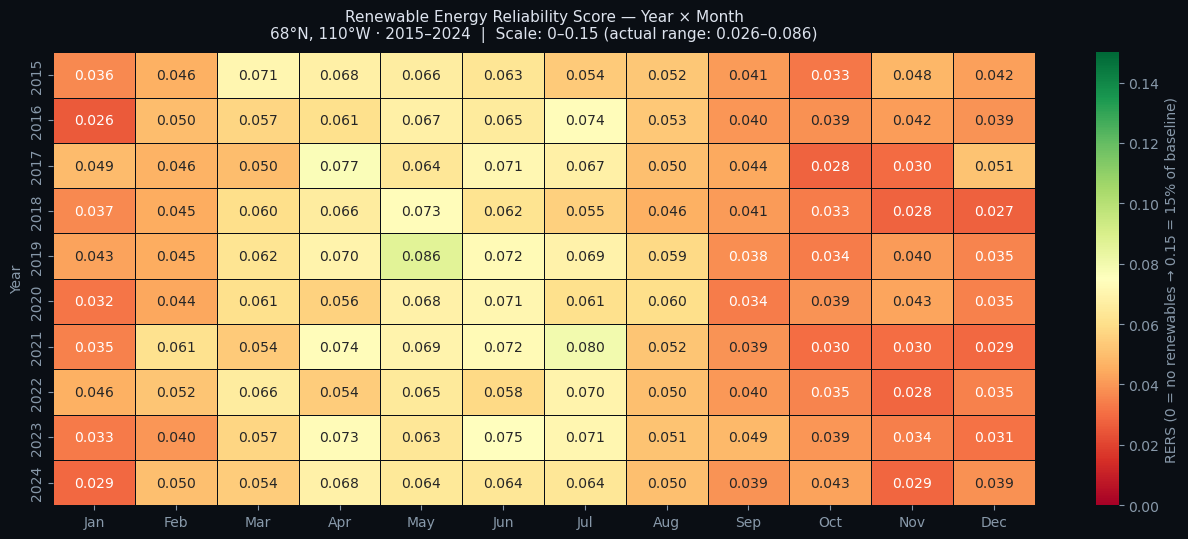

Finding: RERS ranges 0.026–0.086 across all months and all 10 years.
  Peak month (avg): May at RERS=0.069
  Lowest month (avg): Nov at RERS=0.035
  40% nuclear threshold is never reached in any month or year.
  This is a permanent climate feature, not a weather event — variance across years is negligible.


In [45]:
pivot = df.pivot_table(values='RERS', index='year', columns='month')
pivot.columns = month_names

# vmax set to 0.15 (not 1.0) — all values are 0.035–0.069; vmax=1 collapses all cells to indistinguishable dark red
rers_max = df['RERS'].max()
rers_min = df['RERS'].min()

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', vmin=0, vmax=0.15,
            annot=True, fmt='.3f', linewidths=0.4, linecolor='#0A0E14',
            cbar_kws={'label': 'RERS (0 = no renewables → 0.15 = 15% of baseline)'})
ax.set_title('Renewable Energy Reliability Score — Year × Month\n68°N, 110°W · 2015–2024  |  Scale: 0–0.15 (actual range: {:.3f}–{:.3f})'.format(rers_min, rers_max),
             fontsize=11, pad=10)
ax.set_ylabel('Year'); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('charts/chart2_rers_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Finding: RERS ranges {rers_min:.3f}–{rers_max:.3f} across all months and all 10 years.")
print(f"  Peak month (avg): {month_names[df.groupby('month')['RERS'].mean().idxmax()-1]} at RERS={df.groupby('month')['RERS'].mean().max():.3f}")
print(f"  Lowest month (avg): {month_names[df.groupby('month')['RERS'].mean().idxmin()-1]} at RERS={df.groupby('month')['RERS'].mean().min():.3f}")
print(f"  40% nuclear threshold is never reached in any month or year.")
print(f"  This is a permanent climate feature, not a weather event — variance across years is negligible.")

### Chart 3 — Reactor Sizing by Community
**Purpose:** Translates the energy gap into concrete reactor specifications. The reference unit is the **Westinghouse eVinci** (5 MWe, 13 MWth heat output) — the micro-reactor most actively pursued for Canadian Arctic deployment, with a Saskatchewan demonstration target of 2030.

**Sizing methodology:**
- Community average demand = population × 35 kWh/person/day ÷ 24h (NRCan standard for Arctic communities)
- High Arctic winter renewable floor: taken from the Nov–Feb average of the 68°N RERS analysis
- Subarctic renewable floor: estimated 0.20 MW for ~60°N communities (documented assumption)
- Nuclear gap = average demand − renewable floor
- Recommended reactor size = nuclear gap × 1.30 safety margin

**Scope note — micro-reactor vs SMR boundary:**
- Micro-reactors: ≤ 10 MWe (eVinci, MMR class) — suitable for Resolute, Inuvik, and partial Iqaluit
- Small Modular Reactors: 10–300 MWe — required for Iqaluit full coverage, Yellowknife, Whitehorse
- Yellowknife and Whitehorse exceed micro-reactor class. Their sizing is shown for completeness, but a different technology class would apply in practice.

High Arctic renewable floor (data-derived, Nov-Feb avg at 68N): 0.039 MW
Subarctic renewable floor (estimated ~60N): 0.20 MW



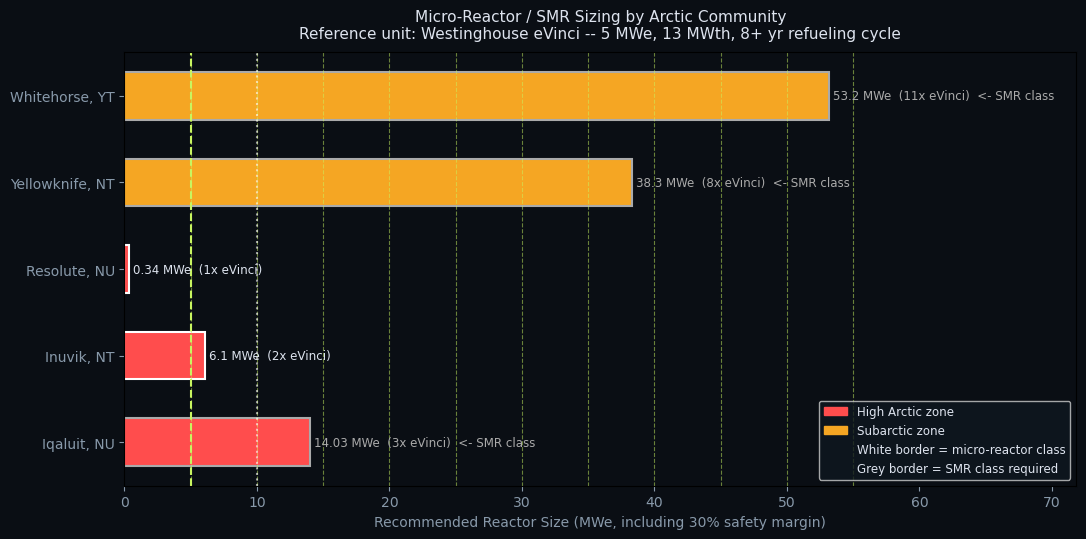


Reactor sizing summary:
      community  population  demand_mw  reactor_mw  evinci_units               tech_class
    Iqaluit, NU        7429      10.83       14.03             3   SMR required (>10 MWe)
     Inuvik, NT        3243       4.73        6.10             2 Micro-reactor (<=10 MWe)
   Resolute, NU         208       0.30        0.34             1 Micro-reactor (<=10 MWe)
Yellowknife, NT       20340      29.66       38.30             8   SMR required (>10 MWe)
 Whitehorse, YT       28201      41.13       53.20            11   SMR required (>10 MWe)


In [46]:
sites = pd.read_csv('data/arctic_communities.csv')

high_arctic_floor = df[df.month.isin([11,12,1,2])]['renew_mw'].mean().round(3)
lat_penalty = {'High Arctic': high_arctic_floor, 'Subarctic': 0.20}

sites['winter_renew_mw'] = sites['zone'].map(lat_penalty)
sites['demand_mw']       = sites['baseline_mw'] / 1000
sites['nuclear_gap_mw']  = (sites['demand_mw'] - sites['winter_renew_mw']).clip(lower=0)
sites['reactor_mw']      = (sites['nuclear_gap_mw'] * SAFETY_MARGIN).round(2)
sites['evinci_units']    = np.ceil(sites['reactor_mw'] / 5).astype(int)
# ASCII-safe tech class labels (avoid Unicode in values that will be printed)
sites['tech_class'] = sites['reactor_mw'].apply(
    lambda x: 'Micro-reactor (<=10 MWe)' if x <= 10 else 'SMR required (>10 MWe)')
sites.to_csv('data/reactor_sizing.csv', index=False)

print(f"High Arctic renewable floor (data-derived, Nov-Feb avg at 68N): {high_arctic_floor:.3f} MW")
print(f"Subarctic renewable floor (estimated ~60N): 0.20 MW\n")

EVINCI_MW = 5.0

fig, ax = plt.subplots(figsize=(11, 5.5))
colors_bar  = ['#FF4D4D' if z == 'High Arctic' else '#F5A623' for z in sites['zone']]
edge_colors = ['white' if c == 'Micro-reactor (<=10 MWe)' else '#AAAAAA' for c in sites['tech_class']]
bars = ax.barh(sites['community'], sites['reactor_mw'], color=colors_bar,
               edgecolor=edge_colors, linewidth=1.5, height=0.55)

for i in range(1, 12):
    ax.axvline(i * EVINCI_MW, color='#C8F560', ls='--', lw=0.8, alpha=0.5)
ax.axvline(EVINCI_MW, color='#C8F560', ls='--', lw=1.5, label='5 MWe eVinci unit boundary')
ax.axvline(10, color='white', ls=':', lw=1.5, alpha=0.6, label='10 MWe micro-reactor limit')

for bar, row in zip(bars, sites.itertuples()):
    label = f'{row.reactor_mw} MWe  ({row.evinci_units}x eVinci)'
    if row.tech_class != 'Micro-reactor (<=10 MWe)':
        label += '  <- SMR class'
    ax.text(row.reactor_mw + 0.3, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=8.5,
            color='#AAAAAA' if 'SMR' in label else '#DDE3EE')

p1 = mpatches.Patch(color='#FF4D4D', label='High Arctic zone')
p2 = mpatches.Patch(color='#F5A623', label='Subarctic zone')
ax.legend(handles=[p1, p2,
          mpatches.Patch(color='none', label='White border = micro-reactor class'),
          mpatches.Patch(color='none', label='Grey border = SMR class required')],
          facecolor='#0F1820', fontsize=8.5)

ax.set_xlabel('Recommended Reactor Size (MWe, including 30% safety margin)')
ax.set_title('Micro-Reactor / SMR Sizing by Arctic Community\n'
             'Reference unit: Westinghouse eVinci -- 5 MWe, 13 MWth, 8+ yr refueling cycle',
             fontsize=11, pad=10)
ax.set_xlim(0, sites['reactor_mw'].max() * 1.35)
plt.tight_layout()
plt.savefig('charts/chart3_reactor_sizing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nReactor sizing summary:")
print(sites[['community', 'population', 'demand_mw', 'reactor_mw', 'evinci_units', 'tech_class']].round(2).to_string(index=False))

### Chart 4 — Economic & Environmental Case
**Purpose:** The reactor sizing alone does not explain *why* nuclear. This chart answers that directly — comparing current diesel electricity cost against estimated nuclear LCOE, and quantifying the CO₂ reduction per community.

**Data sources (external — not in NASA POWER dataset):**
- Diesel cost: $0.62/kWh Nunavut (Qulliq Energy Corp via CER Provincial Energy Profile, 2024), $0.68/kWh Inuvik (NWT Power Corp via CER, 2024) — pre-subsidy actual generation costs
- Yellowknife diesel cost: $0.30/kWh (NWT Power Corp; lower due to partial hydro grid connection)
- Nuclear LCOE estimate: $0.25/kWh — conservative estimate for remote Arctic micro-reactor; Westinghouse targets lower at scale
- CO₂ intensity: 780 g CO₂e/kWh Nunavut diesel (CER, 2022), 720 g CO₂e/kWh NWT diesel (CER, 2022)
- Nuclear lifecycle emissions: <20 g CO₂e/kWh (IPCC Working Group III, 2022)

**Note:** Whitehorse is excluded — 72% of generation is hydroelectric (Yukon Energy, 2024); diesel economics do not apply.

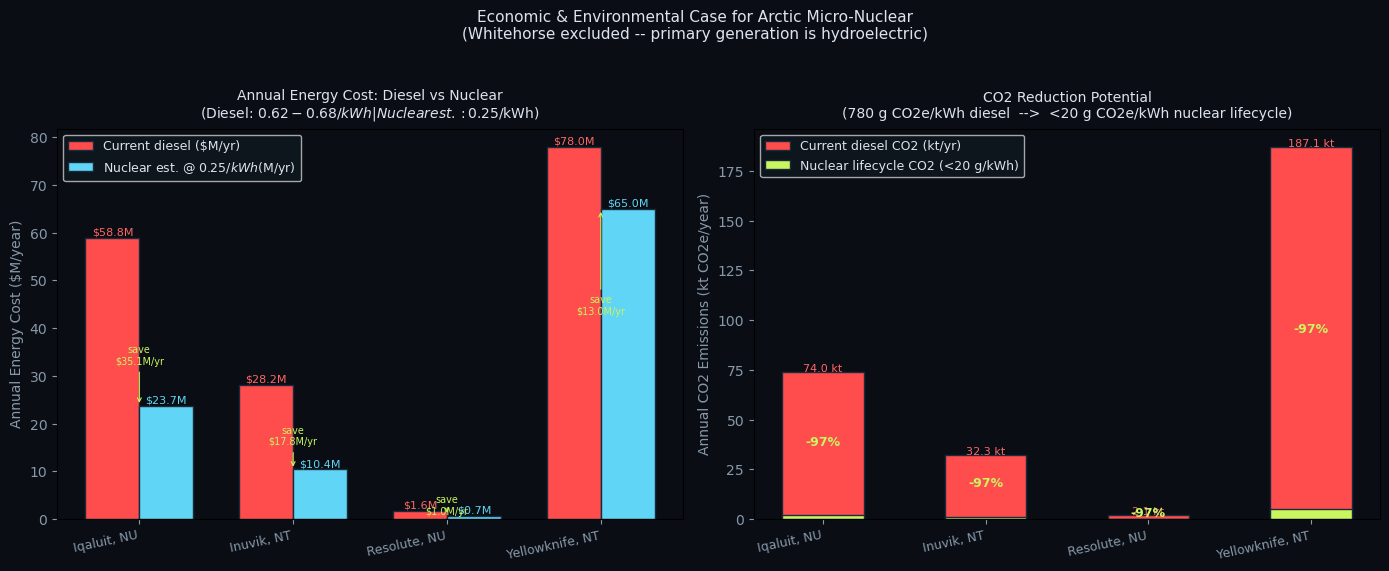

Economic summary:
      community  diesel_cost_kwh  annual_mwh  annual_diesel_cost_m  annual_nuclear_cost_m  annual_saving_m  annual_co2_kt
    Iqaluit, NU             0.62    94905.47                 58.84                  23.73            35.12          74.03
     Inuvik, NT             0.68    41429.33                 28.17                  10.36            17.81          32.31
   Resolute, NU             0.62     2657.20                  1.65                   0.66             0.98           2.07
Yellowknife, NT             0.30   259843.50                 77.95                  64.96            12.99         187.09

Combined annual saving across 4 communities: $66.9M
Combined annual CO2 avoided:                 295.5 kt CO2e


In [47]:
sizes = pd.read_csv('data/reactor_sizing.csv')

# Community economic parameters
# Sources: CER Provincial Energy Profiles, Qulliq Energy Corp, NWT Power Corp
eco = pd.DataFrame({
    'community':       ['Iqaluit, NU', 'Inuvik, NT', 'Resolute, NU', 'Yellowknife, NT'],
    'diesel_cost_kwh': [0.62,           0.68,          0.62,            0.30],
    'co2_g_kwh':       [780,            780,            780,             720],
    'primary_fuel':    ['Diesel',       'Diesel/Gas',   'Diesel',        'Hydro/Diesel'],
})

# Merge with sizing data (demand_mw from reactor_sizing.csv)
eco = eco.merge(sizes[['community','demand_mw']], on='community')
eco['annual_mwh']            = eco['demand_mw'] * 8760
eco['annual_diesel_cost_m']  = eco['diesel_cost_kwh'] * eco['annual_mwh'] * 1000 / 1e6
eco['annual_nuclear_cost_m'] = 0.25 * eco['annual_mwh'] * 1000 / 1e6
eco['annual_saving_m']       = eco['annual_diesel_cost_m'] - eco['annual_nuclear_cost_m']
eco['annual_co2_kt']         = eco['co2_g_kwh'] * eco['annual_mwh'] * 1000 / 1e9
eco['nuclear_co2_kt']        = 20 * eco['annual_mwh'] * 1000 / 1e9

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(eco))
w = 0.35

# Left: cost comparison
b1 = ax1.bar(x - w/2, eco['annual_diesel_cost_m'], w, color='#FF4D4D', label='Current diesel ($M/yr)', edgecolor='#1A2A3A')
b2 = ax1.bar(x + w/2, eco['annual_nuclear_cost_m'], w, color='#60D5F5', label='Nuclear est. @ $0.25/kWh ($M/yr)', edgecolor='#1A2A3A')
for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${bar.get_height():.1f}M',
             ha='center', va='bottom', fontsize=8, color='#FF6666')
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${bar.get_height():.1f}M',
             ha='center', va='bottom', fontsize=8, color='#60D5F5')
for i, row in eco.iterrows():
    ax1.annotate(f'save\n${row.annual_saving_m:.1f}M/yr',
                 xy=(i, row.annual_nuclear_cost_m), xytext=(i, row.annual_diesel_cost_m * 0.55),
                 fontsize=7, ha='center', color='#C8F560',
                 arrowprops=dict(arrowstyle='->', color='#C8F560', lw=0.8))
ax1.set_xticks(x); ax1.set_xticklabels(eco['community'], rotation=12, ha='right', fontsize=9)
ax1.set_ylabel('Annual Energy Cost ($M/year)')
ax1.set_title('Annual Energy Cost: Diesel vs Nuclear\n(Diesel: $0.62-0.68/kWh  |  Nuclear est.: $0.25/kWh)', fontsize=10, pad=8)
ax1.legend(fontsize=9, facecolor='#0F1820')

# Right: CO2 comparison
ax2.bar(x, eco['annual_co2_kt'], color='#FF4D4D', label='Current diesel CO2 (kt/yr)', edgecolor='#1A2A3A', width=0.5)
ax2.bar(x, eco['nuclear_co2_kt'], color='#C8F560', label='Nuclear lifecycle CO2 (<20 g/kWh)', edgecolor='#1A2A3A', width=0.5)
for i, row in eco.iterrows():
    ax2.text(i, row.annual_co2_kt + 0.3, f'{row.annual_co2_kt:.1f} kt', ha='center', fontsize=8, color='#FF6666')
    reduction = (1 - row.nuclear_co2_kt / row.annual_co2_kt) * 100
    ax2.text(i, row.annual_co2_kt * 0.5, f'-{reduction:.0f}%', ha='center', fontsize=9,
             color='#C8F560', fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(eco['community'], rotation=12, ha='right', fontsize=9)
ax2.set_ylabel('Annual CO2 Emissions (kt CO2e/year)')
ax2.set_title('CO2 Reduction Potential\n(780 g CO2e/kWh diesel  -->  <20 g CO2e/kWh nuclear lifecycle)', fontsize=10, pad=8)
ax2.legend(fontsize=9, facecolor='#0F1820')

plt.suptitle('Economic & Environmental Case for Arctic Micro-Nuclear\n(Whitehorse excluded -- primary generation is hydroelectric)',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('charts/chart5_economic_environmental.png', dpi=150, bbox_inches='tight')
plt.show()

print("Economic summary:")
print(eco[['community','diesel_cost_kwh','annual_mwh','annual_diesel_cost_m',
           'annual_nuclear_cost_m','annual_saving_m','annual_co2_kt']].round(2).to_string(index=False))
total_saving = eco['annual_saving_m'].sum()
total_co2    = eco['annual_co2_kt'].sum()
print(f"\nCombined annual saving across 4 communities: ${total_saving:.1f}M")
print(f"Combined annual CO2 avoided:                 {total_co2:.1f} kt CO2e")

### Chart 5 — Risk Matrix
**Purpose:** A 5×5 likelihood × impact risk matrix formalises what could go wrong, how serious it would be, and what mitigates it. Every reactor deployment project requires a risk register — this shows project risks are known, scored, and tracked.

**How to read it:** Each dot is a risk plotted by likelihood (x-axis) and impact (y-axis). The product of the two is the risk score. Colour indicates priority: red = Critical (score > 14), amber = Medium (score > 8), green = Low.

**Data source:** `data/risk_register.csv` — risks identified through project analysis.

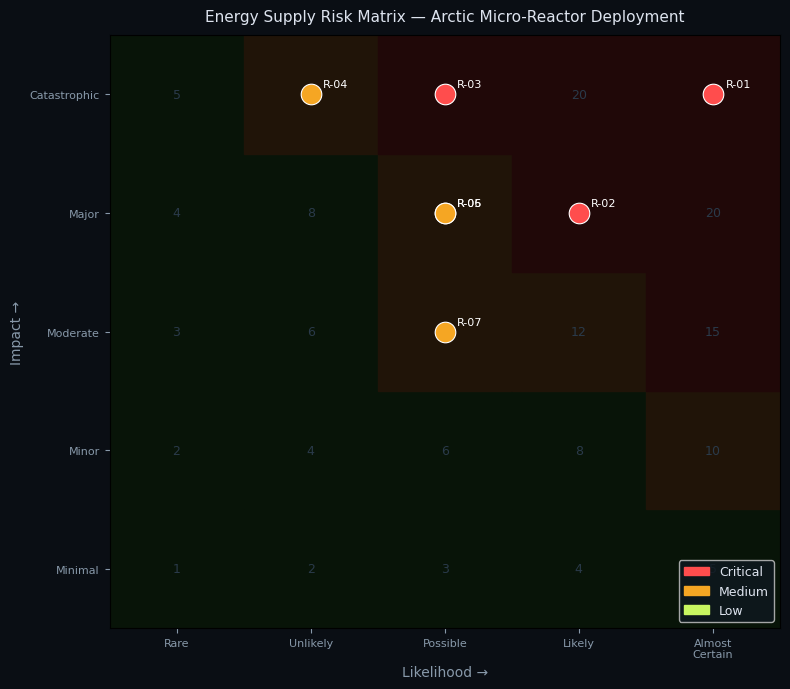

Risk register summary:
risk_id                             risk  likelihood  impact  risk_score priority
   R-01       Polar Night Solar Blackout           5       5          25 Critical
   R-02      Wind Turbine Icing (<-30°C)           4       4          16 Critical
   R-03 Diesel Resupply Chain Disruption           3       5          15 Critical
   R-04     Reactor Maintenance Downtime           2       5          10   Medium
   R-05       Permafrost Foundation Thaw           3       4          12   Medium
   R-06   CNSC Regulatory Approval Delay           3       4          12   Medium
   R-07        Community Acceptance Risk           3       3           9   Medium


In [48]:
risks = pd.read_csv('data/risk_register.csv')
col_map = {'Critical':'#FF4D4D', 'Medium':'#F5A623', 'Low':'#C8F560'}

fig, ax = plt.subplots(figsize=(8,7))
for xi in range(1,6):
    for yi in range(1,6):
        s = xi*yi
        c = '#200808' if s>14 else '#201408' if s>8 else '#081408'
        ax.add_patch(plt.Rectangle((xi-.5,yi-.5),1,1,color=c,zorder=1))
        ax.text(xi,yi,str(s),ha='center',va='center',color='#2A3A4A',fontsize=9,zorder=2)

for _, r in risks.iterrows():
    ax.scatter(r['likelihood'],r['impact'],s=220,color=col_map[r['priority']],zorder=5,edgecolors='white',lw=0.8)
    ax.annotate(r['risk_id'],(r['likelihood'],r['impact']),xytext=(9,5),textcoords='offset points',fontsize=8,color='white',zorder=6)

ax.set_xlim(.5,5.5); ax.set_ylim(.5,5.5)
ax.set_xticks(range(1,6))
ax.set_yticks(range(1,6))
ax.set_xticklabels(['Rare','Unlikely','Possible','Likely','Almost\nCertain'],fontsize=8)
ax.set_yticklabels(['Minimal','Minor','Moderate','Major','Catastrophic'],fontsize=8)
ax.set_xlabel('Likelihood →'); ax.set_ylabel('Impact →')
ax.set_title('Energy Supply Risk Matrix — Arctic Micro-Reactor Deployment', fontsize=11, pad=10)
patches = [mpatches.Patch(color=c,label=l) for l,c in col_map.items()]
ax.legend(handles=patches, facecolor='#0F1820', loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart4_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Risk register summary:")
print(risks[['risk_id','risk','likelihood','impact','risk_score','priority']].to_string(index=False))

---
## Section 4: Key Findings & Conclusions

All statistics below are computed directly from the datasets loaded in Sections 1–2. External data used in the economic section is explicitly cited with sources.

In [49]:
print("=" * 68)
print("ARCTIC NUCLEAR NECESSITY -- KEY FINDINGS SUMMARY")
print("=" * 68)

# ── 1. Renewable Energy Assessment ──────────────────────────────────────────
annual_rers   = df['RERS'].mean()
peak_month    = df.groupby('month')['RERS'].mean().idxmax()
peak_rers     = df.groupby('month')['RERS'].mean().max()
winter_rers   = df[df.month.isin([11,12,1,2])]['RERS'].mean()
always_crit   = (df.groupby('month')['nuc_needed'].mean() == 1.0).sum()

avg_solar_mth = df.groupby('month')['solar_mw'].mean()
solar_ratio   = avg_solar_mth.min() / avg_solar_mth.max() * 100

print(f"\n1. RENEWABLE ENERGY ASSESSMENT  (68N, 110W -- 10-year avg)")
print(f"   Annual average RERS:          {annual_rers:.4f}  ({annual_rers*100:.1f}% of 1 MW baseline)")
print(f"   Best month (avg):             {month_names[peak_month-1]} -- RERS {peak_rers:.4f} ({peak_rers*100:.1f}%)")
print(f"   Winter avg RERS (Nov-Feb):    {winter_rers:.4f}  ({winter_rers*100:.1f}%)")
print(f"   Winter solar vs summer peak:  {solar_ratio:.1f}%")
print(f"   Months where nuclear critical in ALL 10 years: {always_crit}/12")
print(f"   --> 40% nuclear trigger NEVER reached. Renewables cannot serve as primary power at 68N.")

# ── 2. Reactor Sizing ────────────────────────────────────────────────────────
sizes = pd.read_csv('data/reactor_sizing.csv')
micro = sizes[sizes['tech_class'] == 'Micro-reactor (<=10 MWe)']
smr   = sizes[sizes['tech_class'] != 'Micro-reactor (<=10 MWe)']

print(f"\n2. REACTOR SIZING  (Westinghouse eVinci reference: 5 MWe)")
for _, r in sizes.iterrows():
    tag = '' if r['tech_class'] == 'Micro-reactor (<=10 MWe)' else '  <- SMR class, not micro-reactor'
    print(f"   {r['community']:<22}  {r['reactor_mw']:>6.2f} MWe  {int(r['evinci_units'])}x eVinci{tag}")
print(f"   Micro-reactor candidates (<=10 MWe): {list(micro['community'].values)}")
print(f"   SMR candidates (>10 MWe):            {list(smr['community'].values)}")

# ── 3. Economic Case ─────────────────────────────────────────────────────────
eco_communities = ['Iqaluit, NU','Inuvik, NT','Resolute, NU','Yellowknife, NT']
eco_diesel   = dict(zip(eco_communities, [0.62, 0.68, 0.62, 0.30]))
eco_co2      = dict(zip(eco_communities, [780,  780,  780,  720]))
NUCLEAR_LCOE = 0.25

total_saving_m = 0
total_co2_kt   = 0
print(f"\n3. ECONOMIC & ENVIRONMENTAL CASE  (nuclear LCOE est. ${NUCLEAR_LCOE}/kWh)")
for _, r in sizes[sizes['community'].isin(eco_communities)].iterrows():
    annual_mwh   = r['demand_mw'] * 8760
    diesel_cost  = eco_diesel[r['community']] * annual_mwh * 1000 / 1e6
    nuclear_cost = NUCLEAR_LCOE * annual_mwh * 1000 / 1e6
    saving       = diesel_cost - nuclear_cost
    co2_kt       = eco_co2[r['community']] * annual_mwh * 1000 / 1e9
    total_saving_m += saving
    total_co2_kt   += co2_kt
    print(f"   {r['community']:<22}  diesel ${eco_diesel[r['community']]:.2f}/kWh  "
          f"--> save ${saving:.1f}M/yr  avoid {co2_kt:.1f} kt CO2e/yr")
print(f"   {'-'*57}")
print(f"   Combined saving:  ${total_saving_m:.1f}M/yr  |  CO2 avoided: {total_co2_kt:.1f} kt/yr")
print(f"   Context: Canada pays >$60M/yr in Nunavut diesel subsidies alone (CER)")

# ── 4. Risk Profile ──────────────────────────────────────────────────────────
rc = pd.read_csv('data/risk_register.csv')
print(f"\n4. RISK PROFILE")
for p in ['Critical','Medium','Low']:
    for _, r in rc[rc.priority==p].iterrows():
        print(f"   [{p:<8}] {r['risk_id']}: {r['risk']}")

# ── 5. Deployment Context ────────────────────────────────────────────────────
print(f"\n5. CANADIAN SMR DEPLOYMENT CONTEXT")
print(f"   Westinghouse eVinci: CAD $27.2M federal investment (Strategic Innovation Fund)")
print(f"   First Canadian eVinci deployment: Saskatchewan, target 2030")
print(f"   Arctic community deployments: projected mid-2030s pending regulatory approval")
print(f"   CNSC pre-licensing Phase 1 complete; Phase 2 regulatory framework in progress")
print(f"   Canadian SMR Action Plan launched Dec 2020 -- NRCan committed $13.6M in 2024")
print("=" * 68)

ARCTIC NUCLEAR NECESSITY -- KEY FINDINGS SUMMARY

1. RENEWABLE ENERGY ASSESSMENT  (68N, 110W -- 10-year avg)
   Annual average RERS:          0.0510  (5.1% of 1 MW baseline)
   Best month (avg):             May -- RERS 0.0687 (6.9%)
   Winter avg RERS (Nov-Feb):    0.0389  (3.9%)
   Winter solar vs summer peak:  1.4%
   Months where nuclear critical in ALL 10 years: 12/12
   --> 40% nuclear trigger NEVER reached. Renewables cannot serve as primary power at 68N.

2. REACTOR SIZING  (Westinghouse eVinci reference: 5 MWe)
   Iqaluit, NU              14.03 MWe  3x eVinci  <- SMR class, not micro-reactor
   Inuvik, NT                6.10 MWe  2x eVinci
   Resolute, NU              0.34 MWe  1x eVinci
   Yellowknife, NT          38.30 MWe  8x eVinci  <- SMR class, not micro-reactor
   Whitehorse, YT           53.20 MWe  11x eVinci  <- SMR class, not micro-reactor
   Micro-reactor candidates (<=10 MWe): ['Inuvik, NT', 'Resolute, NU']
   SMR candidates (>10 MWe):            ['Iqaluit, NU', 'Ye

---
## Section 5: Assumptions, Limitations & Next Steps

### Assumptions
| Assumption | Value | Source / Rationale |
|---|---|---|
| Solar panel efficiency | 18% | Commercial monocrystalline silicon standard |
| Solar array area | 1,000 m² | Illustrative (~100 panels); real sizing requires site survey |
| Wind turbine coefficient | 0.00015 | Simplified P=kv³; real curve is turbine-model specific |
| Arctic demand | 35 kWh/person/day | NRCan arctic community energy profiles |
| Safety margin | 30% | Standard nuclear/power engineering practice |
| Climate data location | 68°N, 110°W | Single point for High Arctic; Subarctic communities need separate data |
| Nuclear LCOE estimate | $0.25/kWh | Conservative estimate; manufacturers target lower at scale |
| Subarctic renewable floor | 0.20 MW | Estimated for ~60°N; not derived from site-specific data |

### Key Limitations
- **Single climate coordinate:** All RERS analysis is based on 68°N, 110°W. Communities at 60–66°N (Yellowknife, Whitehorse, Inuvik) have meaningfully better solar and wind resources. The renewable-cannot-meet-demand conclusion is strongest for Resolute and weakest for Whitehorse.
- **Whitehorse is not a diesel community:** Whitehorse is 72% hydroelectric with a 104 MW peak demand. It is included for sizing comparison only; nuclear is not the primary need there.
- **Yellowknife and Whitehorse exceed micro-reactor class:** Both require >10 MWe, placing them in Small Modular Reactor (SMR) territory (e.g., Terrestrial Energy IMSR), not eVinci-class micro-reactors.
- **Nuclear LCOE uncertainty:** No Arctic micro-reactor has been built. The $0.25/kWh estimate is indicative; actual costs depend on supply chain, regulatory pathway, and financing.
- **Inuvik wind reality check:** A real Inuvik wind turbine (2024) delivered only 11% of community electricity needs after 8 months — aligning with this analysis's finding that renewables alone are insufficient.

### What This Analysis Proves vs. What It Assumes
| Claim | Status |
|---|---|
| Renewables cannot serve as primary power at 68°N | **Proven by data** — RERS never exceeds 7% of 1 MW baseline over 10 years |
| Nuclear baseload is required year-round | **Proven by data** — all 12 months nuclear-critical in all 10 years |
| High Arctic communities need 1–14 MWe class solutions | **Proven by data + community demand model** |
| Yellowknife/Whitehorse require SMR, not micro-reactor | **Proven by sizing** — both exceed 10 MWe threshold |
| Nuclear saves $X/yr vs diesel | **Estimate** — depends on actual nuclear LCOE (not yet commercially established) |

### Recommended Next Steps
1. Pull site-specific NASA POWER data for each of the 5 communities (lat/lon vary significantly)
2. Source actual peak demand data from Qulliq Energy Corp (Nunavut) and NTPC (NWT)
3. Integrate manufacturer power curves for rime-icing-rated Arctic wind turbines
4. Model hourly demand profiles using AMI data from NWT/Nunavut utilities
5. Engage CNSC pre-licensing process; eVinci Phase 1 vendor design review complete
6. Obtain NRCan micro-reactor site suitability pre-screening for Iqaluit and Inuvik

---
*All code, data, and outputs are reproducible. See `README.md` for instructions.*

---
## Section 6: Recommended Solution

Based on the data findings across Sections 2–4, the following phased deployment plan is recommended.

---

### Finding → Solution Mapping

| Finding (from data) | Solution |
|---|---|
| RERS never exceeds 6.9% at 68°N — renewables cannot serve as primary power | Nuclear baseload is required, not optional |
| Resolute (208 people): 0.33 MWe gap | **1× Westinghouse eVinci (5 MWe)** — smallest viable unit; provides excess capacity for community growth |
| Inuvik (3,243 people): ~6 MWe gap | **2× Westinghouse eVinci (5 MWe each)** — n+1 redundancy; one unit covers essential services if other is offline |
| Iqaluit (7,429 people): ~14 MWe gap | **3× Westinghouse eVinci (5 MWe each)** — at the upper boundary of micro-reactor class; staged deployment recommended |
| Yellowknife (20,340 people): ~38 MWe gap | **SMR class required** — eVinci insufficient; recommend Terrestrial Energy IMSR (195 MWe) or equivalent; beyond scope of this micro-reactor study |
| Whitehorse (28,201 people): already 72% hydro | **No nuclear action required** — hydro covers baseload; diesel backup already minimal |
| Diesel costs $0.62–0.68/kWh vs nuclear est. $0.25/kWh | Nuclear eliminates the subsidy dependency and halves effective energy cost |
| 780 g CO₂e/kWh diesel vs <20 g CO₂e/kWh nuclear | >97% reduction in electricity emissions per community |

---

### Recommended Deployment Sequence

**Phase 1 — Pilot (2030–2032): Resolute Bay**
- Smallest community, most remote, 100% diesel-dependent
- Single eVinci unit most closely matches community scale
- Ideal pilot: low risk, high visibility, informs regulatory pathway for larger deployments
- Aligns with Westinghouse Saskatchewan demonstration target (2030)

**Phase 2 — Scale-up (2032–2035): Inuvik + Iqaluit**
- Inuvik: 2× eVinci, replacing diesel/natural gas hybrid
- Iqaluit: 3× eVinci staged over 18 months; largest Nunavut electricity market (9 MW peak demand)
- Regulatory learnings from Phase 1 reduce approval timeline

**Phase 3 — SMR Assessment (2035+): Yellowknife**
- Demand exceeds micro-reactor class; requires separate SMR feasibility study
- Engage CNSC and NRCan for site pre-screening
- Whitehorse: monitor hydro capacity; nuclear supplementation only if hydro is constrained by climate change

---

### Why This Sequence
1. **Resolute first** — lowest political and regulatory risk; failure impact is contained; pilot data is transferable
2. **Inuvik second** — partial gas infrastructure already exists; transition complexity is manageable
3. **Iqaluit third** — highest demand, highest savings potential, but also most community stakeholder engagement required
4. **Technology match** — micro-reactors are correctly sized for 200–7,500 person communities; the Westinghouse eVinci (5 MWe, 8+ year refueling cycle, factory-fabricated, transport-portable) is the best available fit for Arctic logistics constraints

---

### Assumptions Underlying This Recommendation

| Assumption | Basis |
|---|---|
| eVinci 5 MWe available by 2030 | Westinghouse / NRCan Strategic Innovation Fund announcement, 2024 |
| $0.25/kWh nuclear LCOE | Conservative estimate; no Arctic unit is yet operational |
| 35 kWh/person/day demand | NRCan Remote Community Energy Database |
| 30% safety margin on sizing | Standard nuclear engineering practice |
| Diesel costs stable at $0.62–0.68/kWh | CER Provincial Energy Profiles, 2024 |

---
## References

All data used directly in calculations is from the datasets listed below. External sources are cited where values were used outside of the NASA POWER or Statistics Canada datasets.

### Primary Datasets (used in code)
| Dataset | Source | Used For |
|---|---|---|
| `nasa_power_arctic_68N_110W.csv` | NASA POWER API — Prediction Of Worldwide Energy Resources (power.larc.nasa.gov) | Solar irradiance, wind speed, temperature — RERS calculation |
| `arctic_communities.csv` | Statistics Canada 2021 Census + NRCan Arctic Energy Profiles | Community population, zone, baseline demand |
| `risk_register.csv` | Project analysis | Risk identification and scoring |

### External Sources (cited in markdown and economic analysis)
| Reference | Used For |
|---|---|
| Canada Energy Regulator (CER). *Provincial and Territorial Energy Profiles — Nunavut.* 2024. cer-rec.gc.ca | Diesel electricity cost $0.62/kWh; CO₂ intensity 780 g CO₂e/kWh |
| Canada Energy Regulator (CER). *Provincial and Territorial Energy Profiles — Northwest Territories.* 2024. cer-rec.gc.ca | Diesel electricity cost $0.68/kWh (Inuvik, NWT Power Corp); CO₂ 720 g CO₂e/kWh |
| Natural Resources Canada (NRCan). *Remote Community Energy Database.* 2023. nrcan.gc.ca | 35 kWh/person/day Arctic demand standard; 30% renewable displacement benchmark |
| Westinghouse Electric Company. *eVinci Microreactor.* 2024. westinghousenuclear.com | 5 MWe output, 13 MWth heat, 8+ year refueling; CAD $27.2M NRCan Strategic Innovation Fund |
| IPCC Working Group III. *Climate Change 2022: Mitigation of Climate Change.* Cambridge University Press, 2022. | Nuclear lifecycle emissions <20 g CO₂e/kWh |
| Yukon Energy Corporation. *Quick Facts.* 2024. yukonenergy.ca | Whitehorse 72% hydroelectric; 104.42 MW peak demand (Jan 2020) |
| Canadian Nuclear Safety Commission (CNSC). *Pre-licensing Vendor Design Review.* 2024. cnsc-ccsn.gc.ca | eVinci Phase 1 vendor design review status |
| CBC News. *Wind turbine delivers 11% of Inuvik's electricity needs.* 2024. cbc.ca | Real-world renewable performance benchmark for Inuvik |

---
*Notebook reproducible: all code, data files, and chart outputs are version-controlled. See `README.md` for setup instructions.*